**Student Name: Gbenga Dairo**

**Major: Quantitative Biomedicine**

**Project 2**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import random
from grid_generator import generate_ship
from baseline_strategy_2 import baseline_strategy_2
from developed_strategy import developed_strategy
from mobile_developed_strategy import mobile_developed_strategy
from Astar import a_star_output 
from grid_generator import generate_ship, display_ship

**Returning Number of moves from Project 1 Optimal strategy**

In [2]:
def print_report(title, res):
    print(f"\n {title} ")
    print(f"Total moves to localize (depth): {res['moves']}")

In [3]:
D, seed = 8, 42
grid = generate_ship(D=D, seed=seed)
display_ship(grid)

# Optimal strategy: A* in belief space
opt_str = a_star_output(grid)
print_report("Optimal Strategy", opt_str)

⬛⬛⬛⬛⬛⬛⬛⬛
⬛⬜⬜⬜⬜⬛⬜⬛
⬛⬛⬜⬛⬜⬜⬜⬛
⬛⬛⬜⬜⬜⬜⬛⬛
⬛⬜⬜⬜⬜⬛⬛⬛
⬛⬜⬛⬜⬜⬜⬛⬛
⬛⬜⬜⬜⬜⬜⬜⬛
⬛⬛⬛⬛⬛⬛⬛⬛

 Optimal Strategy 
Total moves to localize (depth): 12


## Answer to Question 4.4

**Comparing the performance of Baseline strategy 2 and the Developed strategy (Third strategy)**

In [4]:
# Ship configuration
D = 15
grid = generate_ship(D, seed=85)
locator_pos = (2, 2)
roomba_pos = (10, 10)

# Range of detector sensitivities
alphas = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

records = []

# Run experiments for each α value
for alpha in alphas:
    print(f'\nRunning experiments for α = {alpha:.2f} ')

    # Setting seed for reproducibility 
    random.seed(85)

    # Baseline Strategy 2
    res_base2 = baseline_strategy_2(grid, locator_pos, roomba_pos, alpha)

    # Resetting seed before running developed strategy 
    random.seed(85)

    # Developed Strategy
    res_dev = developed_strategy(grid, locator_pos, roomba_pos, alpha)

    # Compute normalized utility (bounded between 0 and 1)
    # Higher means better (closer to 1)
    max_cost = res_dev['total_actions'] * 2  # simple normalization denominator
    if max_cost == 0:
        utility_norm = 0
    else:
        utility_norm = 1 - abs(res_dev['utility']) / max_cost
        utility_norm = round(max(0, min(1, utility_norm)), 3)  # clamp to [0,1]

    # Record the two results
    records.append({
        'alpha': alpha,
        'strategy': 'Baseline 2',
        'moves': res_base2['moves'],
        'senses': res_base2['senses'],
        'total': res_base2['total_actions'],
        'utility': None,   # baseline strategy has no utility
        'utility_norm': None
    })
    records.append({
        'alpha': alpha,
        'strategy': 'Developed',
        'moves': res_dev['moves'],
        'senses': res_dev['senses'],
        'total': res_dev['total_actions'],
        'utility': res_dev['utility'],
        'utility_norm': utility_norm
    })

# Convert to DataFrame and summarize
df = pd.DataFrame(records)
print('\nSummary Results')
print(df[['alpha', 'strategy', 'moves', 'senses', 'total', 'utility', 'utility_norm']])



Running experiments for α = 0.05 

Running experiments for α = 0.10 

Running experiments for α = 0.20 
Belief collapsed to (3, 4) (P=1.00) | Utility: -387.000

Running experiments for α = 0.30 

Running experiments for α = 0.40 
Belief collapsed to (2, 2) with P=2.84

Running experiments for α = 0.50 
Belief collapsed to (6, 2) (P=1.00) | Utility: -35.000

Summary Results
    alpha    strategy  moves  senses  total     utility  utility_norm
0    0.05  Baseline 2    200     200    400         NaN           NaN
1    0.05   Developed    200     200    400 -406.495803         0.492
2    0.10  Baseline 2    200     200    400         NaN           NaN
3    0.10   Developed    200     200    400 -406.331529         0.492
4    0.20  Baseline 2    200     200    400         NaN           NaN
5    0.20   Developed    194     194    388 -387.000000         0.501
6    0.30  Baseline 2    200     200    400         NaN           NaN
7    0.30   Developed    200     200    400 -406.750772        

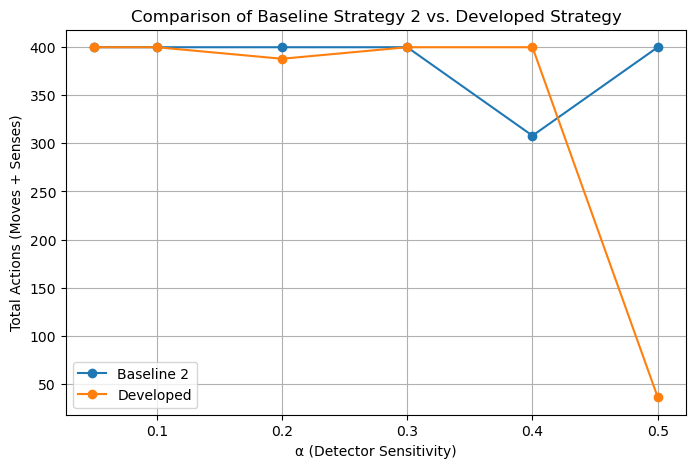

In [5]:
# Plot result
plt.figure(figsize=(8,5))
for strategy in ['Baseline 2', 'Developed']:
    df_sub = df[df['strategy'] == strategy]
    plt.plot(df_sub['alpha'], df_sub['total'], marker='o', label=strategy)

plt.xlabel('α (Detector Sensitivity)')
plt.ylabel('Total Actions (Moves + Senses)')
plt.title('Comparison of Baseline Strategy 2 vs. Developed Strategy')
plt.legend()
plt.grid(True)
plt.show()


## Answer to Question 4.5

**Comparing Baseline strategy 2, Third strategy, and Fourth strategy**

In [6]:
# Compare baseline strategy 2, Developed strategy, and Mobile strategy

D = 15
grid = generate_ship(D, seed=85)
locator_pos = (2, 2)
roomba_pos = (10, 10)

alphas = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
records = []


for alpha in alphas:
    print(f"\nRunning experiments for α = {alpha:.2f} ")

    # Reset random seed for reproducibility
    random.seed(85)

    # Baseline Strategy 2
    res_base2 = baseline_strategy_2(grid, locator_pos, roomba_pos, alpha)
    records.append({
        'alpha': alpha,
        'strategy': 'Baseline 2',
        'moves_R': res_base2['moves'],
        'moves_L': 0,  # LocatorBot static
        'senses': res_base2['senses'],
        'total': res_base2['total_actions'],
        'utility': None
    })

    # Developed Strategy
    random.seed(85)
    res_dev = developed_strategy(grid, locator_pos, roomba_pos, alpha)
    records.append({
        'alpha': alpha,
        'strategy': 'Developed',
        'moves_R': res_dev['moves'],
        'moves_L': 0,  # LocatorBot static
        'senses': res_dev['senses'],
        'total': res_dev['total_actions'],
        'utility': res_dev['utility']
    })

    # Mobile Decision-Theoretic Strategy
    random.seed(85)
    res_mobile = mobile_developed_strategy(grid, locator_pos, roomba_pos, alpha)
    records.append({
        'alpha': alpha,
        'strategy': 'Mobile Developed',
        'moves_R': res_mobile['moves_R'],
        'moves_L': res_mobile['moves_L'],
        'senses': res_mobile['senses'],
        'total': res_mobile['total_actions'],
        'utility': res_mobile['utility']
    })

df = pd.DataFrame(records)
print("\nSummary Results")
print(df[['alpha', 'strategy', 'moves_R', 'moves_L', 'senses', 'total', 'utility']])



Running experiments for α = 0.05 

Running experiments for α = 0.10 

Running experiments for α = 0.20 
Belief collapsed to (3, 4) (P=1.00) | Utility: -387.000
Localized at (3, 5) after 26 R-moves, 74 L-moves, and 100 senses. | U=-199.292

Running experiments for α = 0.30 
Localized at (13, 6) after 25 R-moves, 25 L-moves, and 50 senses. | U=-100.049

Running experiments for α = 0.40 
Belief collapsed to (2, 2) with P=2.84
Localized at (11, 9) after 4 R-moves, 32 L-moves, and 36 senses. | U=-76.850

Running experiments for α = 0.50 
Belief collapsed to (6, 2) (P=1.00) | Utility: -35.000
Localized at (11, 8) after 8 R-moves, 37 L-moves, and 45 senses. | U=-92.398

Summary Results
    alpha          strategy  moves_R  moves_L  senses  total     utility
0    0.05        Baseline 2      200        0     200    400         NaN
1    0.05         Developed      200        0     200    400 -406.495803
2    0.05  Mobile Developed      156       44     200    400 -374.050371
3    0.10        Ba

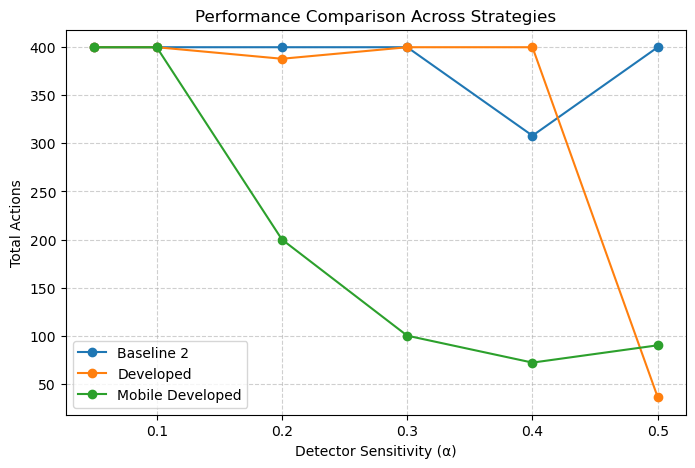

In [7]:
# Plot results
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    for strat in df['strategy'].unique():
        subset = df[df['strategy'] == strat]
        plt.plot(subset['alpha'], subset['total'], marker='o', label=strat)
    plt.xlabel('Detector Sensitivity (α)')
    plt.ylabel('Total Actions')
    plt.title('Performance Comparison Across Strategies')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
except Exception as e:
    print("Plot skipped (matplotlib not available):", e)